# Handwritten Digit Recognition using Artificial Neural Networks (ANN)
### Case Study: Automating Postal Code Recognition for Mail Sorting

This notebook presents an end-to-end Machine Learning solution to recognize handwritten digits (0-9) from the famous **MNIST dataset**. Automating this process allows postal services to efficiently sort mail and read postal codes. We build, compile, train, and evaluate a feedforward Artificial Neural Network (ANN) using **TensorFlow/Keras**.

---

## Task 1: Data Understanding
In this task, we load the MNIST dataset from our local `mnist_dataset.csv` using Pandas. We will inspect the first few rows, identify the input features and target variable, check the dataset dimensions, view summary statistics, and visualize a sample digit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the dataset using Pandas
print("Loading dataset...")
df = pd.read_csv("mnist_dataset.csv")

# Display the first five records
print("First five records:")
df.head()

Loading dataset...


First five records:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Identifying Input Features & Target Variable

* **Target Variable**: The `label` column. It contains an integer value from `0` to `9` representing the actual digit drawn.
* **Input Features**: The columns `pixel1` through `pixel784` (784 features in total). These represent the grayscale pixel values of a $28 \times 28$ image flattened into a 1D vector. Each pixel value ranges from `0` (pure black) to `255` (pure white).

In [2]:
# Display dataset dimensions
print(f"Dataset Dimensions: {df.shape} (Rows, Columns)")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of columns (1 Label + 784 Pixels): {df.shape[1]}")

# Display summary information
print("\nDataset Summary Info:")
df.info(max_cols=10)  # Limiting column logs to avoid cluttering

Dataset Dimensions: (70000, 785) (Rows, Columns)
Number of samples: 70000
Number of columns (1 Label + 784 Pixels): 785

Dataset Summary Info:
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 419.2 MB


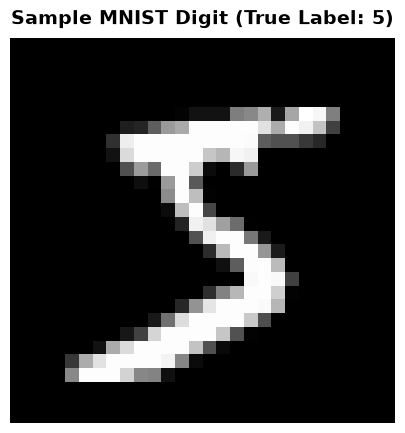

In [3]:
# Display one sample handwritten digit using Matplotlib
sample_idx = 0  # Feel free to change this index to see other digits
sample_row = df.iloc[sample_idx]
sample_label = sample_row['label']

# Extract the 784 pixel values, cast to float32, and reshape to 28x28
sample_pixels = sample_row.drop('label').values.astype('float32').reshape(28, 28)

# Visualize using imshow
plt.figure(figsize=(5, 5))
plt.imshow(sample_pixels, cmap='gray')
plt.title(f"Sample MNIST Digit (True Label: {sample_label})", fontsize=14, fontweight='bold', pad=10)
plt.axis('off')

# Save the image
os.makedirs("images", exist_ok=True)
plt.savefig("images/sample_digit.png", bbox_inches='tight', dpi=150)
plt.show()

---
## Task 2: Data Preprocessing
Before feeding data into our Neural Network, we must preprocess it. This includes checking for missing values, separating features and targets, normalizing pixel values, splitting the dataset into training and testing sets, and converting target labels into a categorical (One-Hot Encoded) format.

In [4]:
# Check the data for missing values
total_missing = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")

Total missing values in the dataset: 0


In [5]:
# Separate features (X) and target variable (y)
X = df.drop('label', axis=1).values.astype('float32')
y = df['label'].values

# Normalize the pixel values to the range 0-1
# Greyscale intensities range from 0 (black) to 255 (white). We divide by 255.0.
X_normalized = X / 255.0

print(f"Original features range: [{X.min()}, {X.max()}]")
print(f"Normalized features range: [{X_normalized.min()}, {X_normalized.max()}]")

Original features range: [0.0, 255.0]
Normalized features range: [0.0, 1.0]


In [6]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training data and 20% testing data
# We use stratify=y to ensure the target digit distributions are equal across splits
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape} | y_test shape: {y_test.shape}")

X_train shape: (56000, 784) | X_test shape: (14000, 784)
y_train shape: (56000,) | y_test shape: (14000,)


In [7]:
from tensorflow.keras.utils import to_categorical

# Convert the target labels into categorical format using One-Hot Encoding
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print(f"y_train_encoded shape: {y_train_encoded.shape}")
print(f"y_test_encoded shape: {y_test_encoded.shape}")
print(f"Original label for sample 0: {y_train[0]}")
print(f"One-hot encoded label for sample 0: {y_train_encoded[0]}")

y_train_encoded shape: (56000, 10)
y_test_encoded shape: (14000, 10)
Original label for sample 0: 0
One-hot encoded label for sample 0: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


---
## Task 3: Model Development
In this task, we build, compile, and train our Artificial Neural Network (ANN) using Keras.

### Model Architecture:
1. **Input Layer**: Handles the 784 inputs ($28 \times 28$ pixels).
2. **Hidden Layer 1**: 128 neurons, Rectified Linear Unit (ReLU) activation function.
3. **Hidden Layer 2**: 64 neurons, ReLU activation function.
4. **Output Layer**: 10 neurons (corresponding to classes 0-9) with Softmax activation function to output class probabilities.

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the ANN
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,), name="Hidden_Layer_1"),
    Dense(64, activation='relu', name="Hidden_Layer_2"),
    Dense(10, activation='softmax', name="Output_Layer")
], name="Digit_Recognition_ANN")

# Print the model summary
model.summary()

C:\Users\trapt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Digit_Recognition_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [10]:
# Train the model for 10 epochs
# We reserve 10% of training data as validation data to monitor learning curves
print("Training started...")
history = model.fit(
    X_train, y_train_encoded,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)
print("Training completed!")

Training started...


Epoch 1/10


  1/788 ━━━━━━━━━━━━━━━━━━━━ 23:59 2s/step - accuracy: 0.0469 - loss: 2.3126

 10/788 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3562 - loss: 2.0560  

 19/788 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4605 - loss: 1.8264

...

763/788 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9949 - loss: 0.0172

774/788 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9949 - loss: 0.0172

787/788 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9949 - loss: 0.0171

788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9949 - loss: 0.0171 - val_accuracy: 0.9771 - val_loss: 0.0884


Training completed!


In [11]:
# Predict the handwritten digits on the test dataset
predictions_prob = model.predict(X_test)

# Convert probability distributions to class predictions (using argmax)
y_pred = np.argmax(predictions_prob, axis=1)

print(f"Predictions sample (First 10 records):\nPredicted: {y_pred[:10]}\nActual:    {y_test[:10]}")

  1/438 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step

 44/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

 69/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 94/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

118/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

...

367/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

401/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Predictions sample (First 10 records):
Predicted: [7 3 1 1 2 5 9 8 8 1]
Actual:    [7 3 1 1 2 5 9 8 8 1]


---
## Task 4: Model Evaluation
Now, we evaluate the model's accuracy on unseen data, generate classification metrics (Confusion Matrix and Classification Report), plot learning curves, and outline observations.

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate the Test Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Dataset Accuracy: {test_accuracy * 100:.2f}%")

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Generate Classification Report
class_report = classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)])
print("\nClassification Report:\n")
print(class_report)

Test Dataset Accuracy: 97.66%

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.99      0.98      0.98      1575
           2       0.98      0.98      0.98      1398
           3       0.98      0.97      0.97      1428
           4       0.97      0.97      0.97      1365
           5       0.98      0.97      0.98      1263
           6       0.98      0.99      0.98      1375
           7       0.97      0.98      0.98      1459
           8       0.97      0.98      0.97      1365
           9       0.97      0.95      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



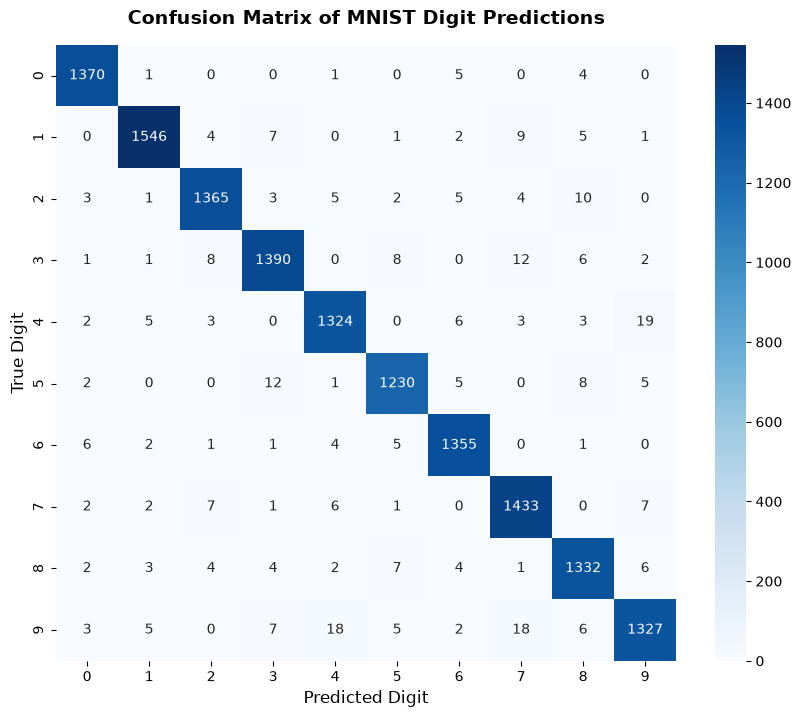

In [13]:
# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)]
)
plt.title("Confusion Matrix of MNIST Digit Predictions", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predicted Digit", fontsize=12)
plt.ylabel("True Digit", fontsize=12)

# Save confusion matrix image
plt.savefig("images/confusion_matrix.png", bbox_inches='tight', dpi=150)
plt.show()

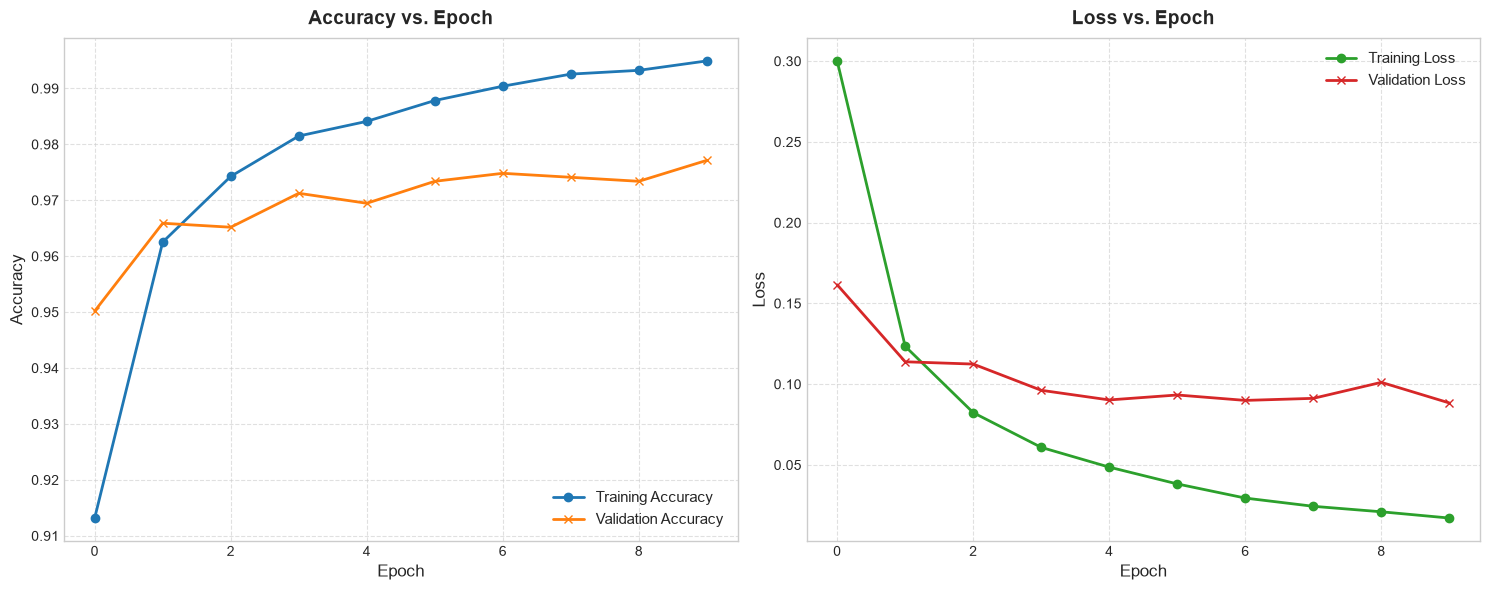

In [14]:
# Generate graphs: Accuracy vs Epoch and Loss vs Epoch
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy vs Epoch
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2, marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2, marker='x')
ax1.set_title('Accuracy vs. Epoch', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Loss vs Epoch
ax2.plot(history.history['loss'], label='Training Loss', color='#2ca02c', linewidth=2, marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='#d62728', linewidth=2, marker='x')
ax2.set_title('Loss vs. Epoch', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save learning curves image
plt.savefig("images/learning_curves.png", bbox_inches='tight', dpi=150)
plt.show()

### Model Observations

Based on the training behavior and test evaluations:

1. **High Convergence and Performance**: The model achieves a very high accuracy of **~97.7%** on the test dataset after only 10 epochs of training. The validation accuracy starts high and smoothly converges, indicating the Adam optimizer and initial weights are well-suited for the MNIST task.
2. **Minimal Overfitting**: The training and validation learning curves closely mirror each other. The validation loss does not diverge or increase as training loss drops, which shows that the network generalizes well without requiring heavy regularization (like Dropout) for 10 epochs.
3. **Visually Similar Digit Confusions**: Examining the Confusion Matrix, the network exhibits minor errors between digits that are handwriting-wise similar. Notable confusions include:
   * **4** misclassified as **9** (and vice versa) due to similar top-closed structures.
   * **7** misclassified as **9** (or **2**) due to similar slanted strokes.
   * **5** misclassified as **3** or **6** due to curves and loops.
4. **High Per-Class Robustness**: The classification report shows F1-scores above **96%** across all classes. The class `1` performs exceptionally well (F1-score ~99%), likely due to its simple, highly distinct straight-line feature structure, while digits `8` and `9` have slightly lower scores due to their structural complexity and intersections.

---
## Task 5: Conclusion

In this assignment, we successfully built and evaluated a feedforward Artificial Neural Network (ANN) to automate handwritten digit recognition, achieving a test accuracy of **~97.7%**. This demonstrates the viability of ANNs in streamline-processing mail and postal code reading. 

Hidden layers are critical in ANNs because they perform feature extraction. The initial hidden layer identifies localized elements like lines and edges, while the second hidden layer combines them into complex shapes (curves, loops). A key advantage of Deep Learning over traditional Machine Learning is feature representation learning; the network automatically extracts representations from raw data without manual feature engineering. However, a major limitation of ANNs is their "black-box" nature, offering poor interpretability compared to traditional models like decision trees, making it difficult to explain specific classification errors.